In [25]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.stats import skew, kurtosis, norm, chi2

In [26]:
def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

def fmt(val, sig=""):
    return f"{val:.4f}{sig}"

def z_pval(z):
    return 2 * norm.sf(abs(z))

def build_row(r):
    r = np.asarray(r, dtype=float)
    T = len(r)
    mu = r.mean()
    sigma = ((r - mu) ** 2).mean() ** 0.5
    sk = ((r - mu) ** 3).mean() / sigma**3
    ek = ((r - mu) ** 4).mean() / sigma**4 - 3
    jb = T / 6 * (sk**2 + ek**2 / 4)
    jb_p = chi2.sf(jb, df=2)
    p_mu = z_pval(mu / (sigma / T**0.5))
    p_sk = z_pval(sk / (6 / T) ** 0.5)
    p_ek = z_pval(ek / (24 / T) ** 0.5)
    return {
        "Mean": fmt(mu, stars(p_mu)),
        "Std Dev": fmt(sigma),
        "Skewness": fmt(sk, stars(p_sk)),
        "Excess Kurtosis": fmt(ek, stars(p_ek)),
        "Minimum": fmt(r.min()),
        "Maximum": fmt(r.max()),
        "Jarque-Bera": fmt(jb, stars(jb_p)),
    }

1.1 Consider the daily stock returns of American Express (AXP), Caterpillar(CAT), and Starbucks (SBUX) from January 1999 to December 2008. The data are simple returns given in the ﬁle `d-3stocks9908.txt` (date, axp, cat, sbux).

In [27]:
df11 = pd.read_csv("data/d-3stocks9908.txt", sep=r"\s+")
stocks11 = df11.columns[1:]
ret_pct_11 = df11[stocks11] * 100
log_ret_pct_11 = np.log(df11[stocks11] + 1) * 100

tickers = ["QQQ"]
raw = yf.download(tickers, start="2016-03-17", end="2026-03-20", auto_adjust=True, progress=False)["Close"]
simple_ret_my = raw.pct_change().dropna()
log_ret_my = np.log(simple_ret_my + 1) * 100

rows_s = {col.upper(): build_row(ret_pct_11[col]) for col in stocks11}
rows_s |= {t: build_row(simple_ret_my[t] * 100) for t in tickers}

rows_l = {col.upper(): build_row(log_ret_pct_11[col]) for col in stocks11}
rows_l |= {t: build_row(log_ret_my[t]) for t in tickers}

print(f"Daily Simple Returns (%)  AXP/CAT/SBUX n={len(ret_pct_11)} [1999-2008]  |  QQQ/MCD/KO/^GSPC n={len(simple_ret_my)} [2016-2026]")
print("Signif. codes:  *** 0.001  ** 0.01  * 0.05\n")
display(pd.DataFrame(rows_s).T)

print(f"\nDaily Log Returns (%)  AXP/CAT/SBUX n={len(log_ret_pct_11)} [1999-2008]  |  QQQ/MCD/KO/^GSPC n={len(log_ret_my)} [2016-2026]")
print("Signif. codes:  *** 0.001  ** 0.01  * 0.05\n")
display(pd.DataFrame(rows_l).T)

Daily Simple Returns (%)  AXP/CAT/SBUX n=2515 [1999-2008]  |  QQQ/MCD/KO/^GSPC n=2515 [2016-2026]
Signif. codes:  *** 0.001  ** 0.01  * 0.05



,Mean,Std Dev,Skewness,Excess Kurtosis,Minimum,Maximum,Jarque-Bera
AXP,0.0146,2.4457,-0.0346,6.0553***,-17.5949,17.9266,3842.8005***
CAT,0.0595,2.1692,0.0117,4.4592***,-14.5175,14.7229,2083.7786***
SBUX,0.0481,2.6821,-0.0825,8.7549***,-28.2862,14.6354,8034.9961***
QQQ,0.0806**,1.3973,-0.1924***,7.9500***,-11.9788,12.0031,6638.6686***



Daily Log Returns (%)  AXP/CAT/SBUX n=2515 [1999-2008]  |  QQQ/MCD/KO/^GSPC n=2515 [2016-2026]
Signif. codes:  *** 0.001  ** 0.01  * 0.05



,Mean,Std Dev,Skewness,Excess Kurtosis,Minimum,Maximum,Jarque-Bera
AXP,-0.0154,2.4524,-0.3366***,6.4940***,-19.3523,16.4892,4466.8422***
CAT,0.0359,2.1711,-0.2019***,4.7009***,-15.6859,13.7349,2332.7850***
SBUX,0.0119,2.6954,-0.5974***,12.9081***,-33.2487,13.6586,17609.9526***
QQQ,0.0708*,1.3994,-0.4005***,8.1150***,-12.7592,11.3356,6968.1869***


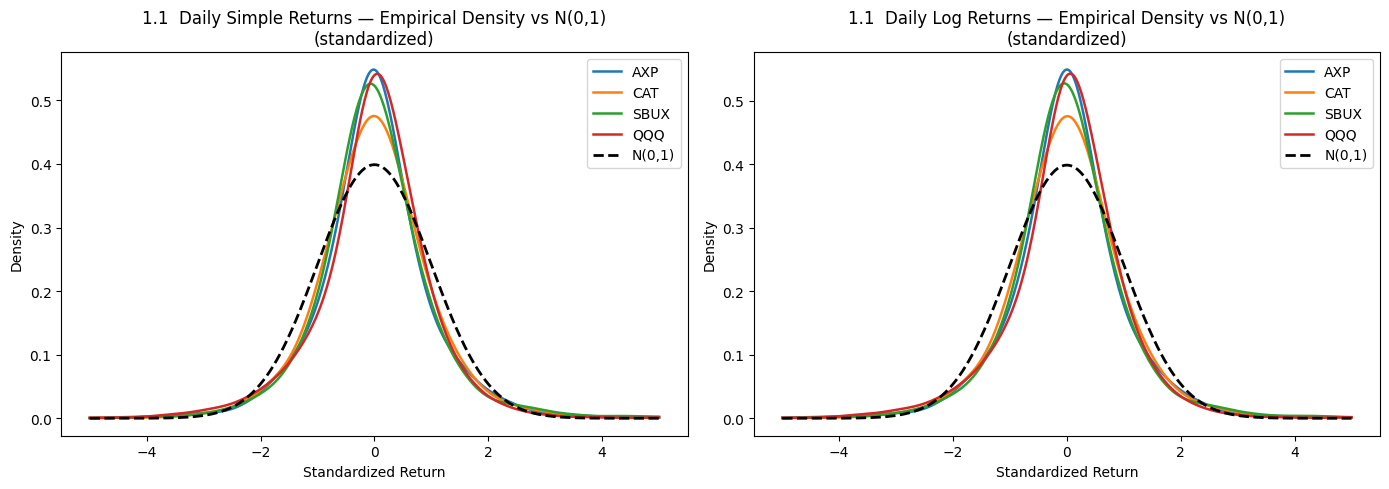

In [28]:
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-5, 5, 500)

for ax, (series, title) in zip(axes, [
    (
        {"AXP": ret_pct_11["axp"], "CAT": ret_pct_11["cat"],
         "SBUX": ret_pct_11["sbux"], "QQQ": simple_ret_my["QQQ"] * 100},
        "1.1  Daily Simple Returns — Empirical Density vs N(0,1)"
    ),
    (
        {"AXP": log_ret_pct_11["axp"], "CAT": log_ret_pct_11["cat"],
         "SBUX": log_ret_pct_11["sbux"], "QQQ": log_ret_my["QQQ"]},
        "1.1  Daily Log Returns — Empirical Density vs N(0,1)"
    ),
]):
    for label, r in series.items():
        r_std = (r - r.mean()) / r.std()
        kde = gaussian_kde(r_std, bw_method=0.3)
        ax.plot(x, kde(x), linewidth=1.8, label=label)
    ax.plot(x, norm.pdf(x), "k--", linewidth=2, label="N(0,1)")
    ax.set_title(title + "\n(standardized)")
    ax.set_xlabel("Standardized Return")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

1.2. Answer the same questions as in Exercise 1.1 but using monthly stock returns for General Motors (GM), CRSP value-weighted index (VW), CRSP equalweighted index (EW), and S&P composite index from January 1975 to December 2008. The returns of the indexes include dividend distributions. Data ﬁle is `m-gm3dx7508.txt` (date, gm, vw, ew, sp).

In [29]:
df = pd.read_csv("data/m-gm3dx7508.txt", sep=r"\s+")
stocks = df.columns[1:]
ret_pct = df[stocks] * 100
log_ret_pct = np.log(df[stocks] + 1) * 100
n = len(ret_pct)

rows_s = {col.upper(): build_row(ret_pct[col]) for col in stocks}
rows_l = {col.upper(): build_row(log_ret_pct[col]) for col in stocks}

print(f"Monthly Simple Returns (%)  n = {n}  [1975-2008]")
print("Signif. codes:  *** 0.001  ** 0.01  * 0.05\n")
display(pd.DataFrame(rows_s).T)

print(f"\nMonthly Log Returns (%)  n = {n}  [1975-2008]")
print("Signif. codes:  *** 0.001  ** 0.01  * 0.05\n")
display(pd.DataFrame(rows_l).T)

Monthly Simple Returns (%)  n = 408  [1975-2008]
Signif. codes:  *** 0.001  ** 0.01  * 0.05



,Mean,Std Dev,Skewness,Excess Kurtosis,Minimum,Maximum,Jarque-Bera
GM,0.5568,9.2613,-0.3849**,2.0729***,-38.9313,27.6619,83.1219***
VW,1.0118***,4.5019,-0.7454***,2.6939***,-22.5363,14.1600,161.1538***
EW,1.3314***,5.5890,-0.3012*,4.3697***,-27.2248,29.9260,330.7799***
SP,0.7301***,4.3546,-0.5726***,2.2945***,-21.7630,13.1767,111.8011***



Monthly Log Returns (%)  n = 408  [1975-2008]
Signif. codes:  *** 0.001  ** 0.01  * 0.05



,Mean,Std Dev,Skewness,Excess Kurtosis,Minimum,Maximum,Jarque-Bera
GM,0.1102,9.5785,-1.0274***,4.0553***,-49.3171,24.4215,351.3549***
VW,0.9046***,4.5550,-1.0549***,3.9717***,-25.5361,13.2431,343.8302***
EW,1.1670***,5.6191,-0.8392***,5.2830***,-31.7795,26.1795,522.3638***
SP,0.6319**,4.3968,-0.8580***,3.3659***,-24.5428,12.3780,242.6519***


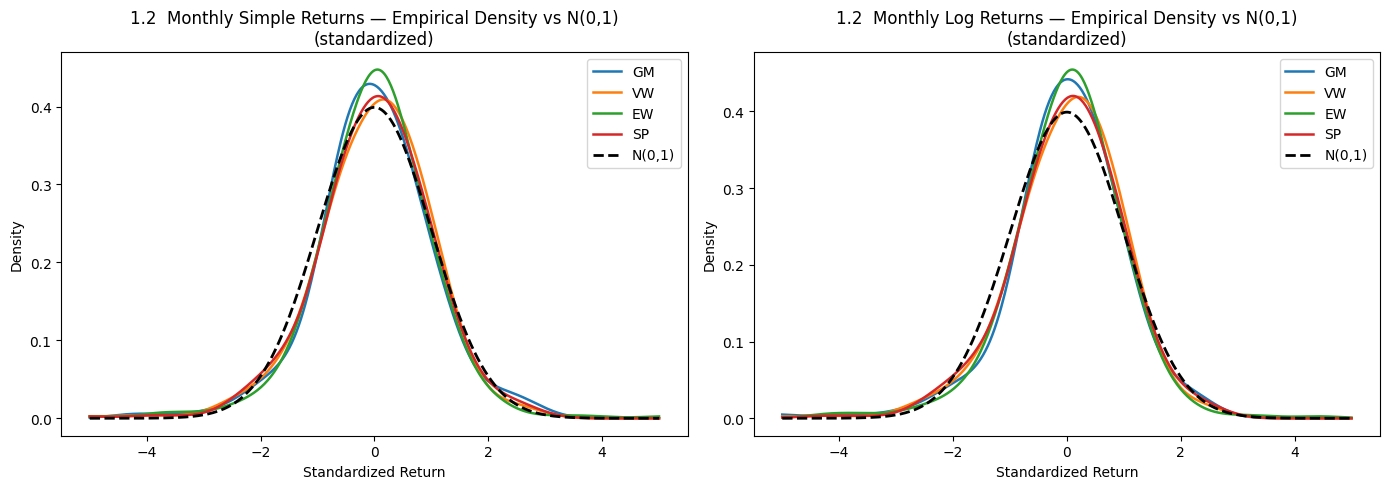

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-5, 5, 500)

for ax, (series, title) in zip(axes, [
    (
        {"GM": ret_pct["gm"], "VW": ret_pct["vw"],
         "EW": ret_pct["ew"], "SP": ret_pct["sp"]},
        "1.2  Monthly Simple Returns — Empirical Density vs N(0,1)"
    ),
    (
        {"GM": log_ret_pct["gm"], "VW": log_ret_pct["vw"],
         "EW": log_ret_pct["ew"], "SP": log_ret_pct["sp"]},
        "1.2  Monthly Log Returns — Empirical Density vs N(0,1)"
    ),
]):
    for label, r in series.items():
        r_std = (r - r.mean()) / r.std()
        kde = gaussian_kde(r_std, bw_method=0.4)
        ax.plot(x, kde(x), linewidth=1.8, label=label)
    ax.plot(x, norm.pdf(x), "k--", linewidth=2, label="N(0,1)")
    ax.set_title(title + "\n(standardized)")
    ax.set_xlabel("Standardized Return")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

1.3. Consider the monthly stock returns of S&P composite index from January 1975 to December 2008 in Exercise 1.2. Answer the following questions:

**1. What is the average annual log return over the data span?**

$$r_{\text{month},i} = \ln(1 + R_i)$$

$$r_{\text{annual}} = \sum_{i=1}^{12} r_{\text{month},i} = \ln\prod_{i=1}^{12}(1 + R_i)$$

$$\bar{r}_{\text{annual}} = \frac{1}{T}\sum_{t=1}^{T} r_{\text{annual},t}, \quad T = 34$$

In [31]:
sp_log_ret = log_ret_pct["sp"]

# sum 12 monthly log returns (%) per year → annual log return (%), then average across 34 years, /100 to get decimal
annual_log_ret = np.reshape(sp_log_ret.values, [-1, 12]).sum(axis=1)
annual_log_ret.mean() / 100

np.float64(0.07583246929284704)

2. Assume that there were no transaction costs. If one invested $1.00 on the S&P composite index at the beginning of 1975, what was the value of the investment at the end of 2008?

In [32]:
np.exp(sp_log_ret.sum() / 100)

np.float64(13.1747742025844)